<a href="https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/01_Text_to_Numbers/notebooks/01_text_to_numbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔢 Text to Numbers: Every Representation You Need to Know

| Method | Year | Key Idea | Best For |
|---|---|---|---|
| **One-Hot Encoding** | 1970s | Every word is a unique slot | Category labels |
| **Bag of Words (BoW)** | 1954 | Count word occurrences | Simple classification |
| **TF-IDF** | 1972 | Rare words matter more | Search, ranking |
| **Word2Vec (CBOW)** | 2013 | Predict center word from context | Word analogies |
| **Word2Vec (Skip-gram)** | 2013 | Predict context from center word | Rare words |
| **GloVe** | 2014 | Global co-occurrence statistics | NLP transfer |
| **FastText** | 2016 | Subword n-grams (handles typos!) | Morphology-rich languages |

**The constant through ALL of these:** Once we have vectors, we use **Cosine Similarity** to measure how similar two texts are.

**The big question we answer at the end:** *Why cosine similarity — and NOT Euclidean distance?*

> **Note:** Transformer-based embeddings (BERT, SBERT) come in a later session when we cover the Attention mechanism.


In [1]:
# Install everything we need (run once)
!pip install gensim scikit-learn matplotlib pandas numpy seaborn --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from gensim.models import Word2Vec, FastText
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#0d1117'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['text.color']       = '#e6edf3'
plt.rcParams['axes.labelcolor']  = '#e6edf3'
plt.rcParams['xtick.color']      = '#e6edf3'
plt.rcParams['ytick.color']      = '#e6edf3'
plt.rcParams['grid.color']       = '#21262d'

print('✅ All imports ready!')

✅ All imports ready!


## 🧩 The Core Problem

Computers only understand numbers. `"cat"` and `"kitten"` are just byte sequences — identical closeness to a computer.

We need to convert text → numbers **while preserving meaning**.

With raw strings: `"king" - "man" + "woman"` = ❌ impossible  
With embeddings: `vector(king) - vector(man) + vector(woman) ≈ vector(queen)` ✅

---
## 1️⃣ One-Hot Encoding

**Idea:** Give each word in your vocabulary a unique position. That word gets a `1`, everything else gets `0`.

**Analogy:** Hotel room numbers — each guest (word) has exactly ONE room (position). No two guests share a room.

**Vocabulary of 5 words:** [cat, dog, loves, sat, mat]  
`cat` → [1, 0, 0, 0, 0]  
`dog` → [0, 1, 0, 0, 0]

In [3]:
# ── One-Hot: build from scratch ────────────────────────────────────────────
corpus = [
    "the cat sat on the mat",
    "the dog sat on the mat",
    "the cat loves the dog",
]

# 👇 Build vocabulary: sorted unique words
vocab = sorted(set(" ".join(corpus).split()))
print(f"Vocabulary ({len(vocab)} words): {vocab}")

def one_hot(sentence, vocab):
    vec = np.zeros(len(vocab))                # start with all zeros
    for word in sentence.split():
        if word in vocab:
            vec[vocab.index(word)] = 1        # set the word's position to 1
    return vec

for sent in corpus:
    print(f"\n'{sent}'")
    print(f"  → {one_hot(sent, vocab).astype(int)}")  # show as ints for clarity

Vocabulary (7 words): ['cat', 'dog', 'loves', 'mat', 'on', 'sat', 'the']

'the cat sat on the mat'
  → [1 0 0 1 1 1 1]

'the dog sat on the mat'
  → [0 1 0 1 1 1 1]

'the cat loves the dog'
  → [1 1 1 0 0 0 1]


In [4]:
# ❌ The problem: One-Hot has ZERO semantic information

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

cat = one_hot("cat", vocab)
dog = one_hot("dog", vocab)
mat = one_hot("mat", vocab)

print("Similarity (cat, dog):", cosine_sim(cat, dog), "← should be HIGH (both animals)")
print("Similarity (cat, mat):", cosine_sim(cat, mat), "← should be LOW (cat ≠ mat)")
print()
print("❌ Both are 0.0 — One-Hot treats every word as equally different from every other word.")
print("   The vector for 'cat' has NO IDEA that 'dog' is nearby in meaning.")

Similarity (cat, dog): 0.0 ← should be HIGH (both animals)
Similarity (cat, mat): 0.0 ← should be LOW (cat ≠ mat)

❌ Both are 0.0 — One-Hot treats every word as equally different from every other word.
   The vector for 'cat' has NO IDEA that 'dog' is nearby in meaning.


---
## 2️⃣ Bag of Words (BoW)

**Idea:** Instead of encoding one word, encode an entire DOCUMENT as a count of all its words.

**Analogy:** Shake a book in a bag. Count how many times each word falls out. Order doesn't matter.

**"The cat sat"** → {the: 1, cat: 1, sat: 1}  
**"The the the"** → {the: 3}  ← longer repetition = larger vector

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Movie plot summaries
movies = [
    "Two imprisoned men bond over years finding solace through acts of decency",
    "An aging patriarch transfers control of his crime empire to his reluctant son",
    "A thief who steals corporate secrets through dream sharing technology",
    "The aging patriarch of an organized crime dynasty transfers control to his son",   # very similar to M2!
    "A young boy discovers he is the chosen one destined to battle evil forces",
]
labels = ["Shawshank", "Godfather", "Inception", "Godfather II", "Harry Potter"]

# 👇 stop_words='english' removes 'the', 'a', 'of' etc.
bow_vec = CountVectorizer(stop_words='english')
bow_matrix = bow_vec.fit_transform(movies)

vocab_bow = bow_vec.get_feature_names_out()
print(f"Vocabulary: {len(vocab_bow)} words")
print(f"Words: {list(vocab_bow)}")

df_bow = pd.DataFrame(bow_matrix.toarray(), columns=vocab_bow, index=labels)
print("\nBag of Words matrix:")
print(df_bow)

Vocabulary: 33 words
Words: ['acts', 'aging', 'battle', 'bond', 'boy', 'chosen', 'control', 'corporate', 'crime', 'decency', 'destined', 'discovers', 'dream', 'dynasty', 'empire', 'evil', 'finding', 'forces', 'imprisoned', 'men', 'organized', 'patriarch', 'reluctant', 'secrets', 'sharing', 'solace', 'son', 'steals', 'technology', 'thief', 'transfers', 'years', 'young']

Bag of Words matrix:
              acts  aging  battle  bond  boy  chosen  control  corporate  \
Shawshank        1      0       0     1    0       0        0          0   
Godfather        0      1       0     0    0       0        1          0   
Inception        0      0       0     0    0       0        0          1   
Godfather II     0      1       0     0    0       0        1          0   
Harry Potter     0      0       1     0    1       1        0          0   

              crime  decency  ...  secrets  sharing  solace  son  steals  \
Shawshank         0        1  ...        0        0       1    0       0 

In [6]:
# Now we can measure similarity!
bow_sim = cosine_similarity(bow_matrix)

sim_df = pd.DataFrame(bow_sim, index=labels, columns=labels)
print("Cosine Similarity (BoW):")
print(sim_df.round(3))

print(f"\nGodfather vs Godfather II: {bow_sim[1,3]:.3f}  ← should be HIGHEST")
print(f"Shawshank vs Inception:    {bow_sim[0,2]:.3f}  ← should be LOW")
print("\n❌ Problem: doesn't understand that 'crime' and 'dynasty' are related concepts.")

Cosine Similarity (BoW):
              Shawshank  Godfather  Inception  Godfather II  Harry Potter
Shawshank           1.0       0.00        0.0          0.00           0.0
Godfather           0.0       1.00        0.0          0.75           0.0
Inception           0.0       0.00        1.0          0.00           0.0
Godfather II        0.0       0.75        0.0          1.00           0.0
Harry Potter        0.0       0.00        0.0          0.00           1.0

Godfather vs Godfather II: 0.750  ← should be HIGHEST
Shawshank vs Inception:    0.000  ← should be LOW

❌ Problem: doesn't understand that 'crime' and 'dynasty' are related concepts.


---
## 3️⃣ TF-IDF — Rare Words Matter More

**TF** (Term Frequency) = how often does this word appear in THIS document?  
**IDF** (Inverse Document Frequency) = how RARE is this word across ALL documents?

`TF-IDF = TF × log(N / df)`  
- Word in EVERY doc → IDF ≈ 0 → weight ≈ 0 ("the", "a" — useless)  
- Word in ONE doc → IDF is HIGH → strongly identifies this document

**Analogy:** If everyone at a party says "hello", it tells you nothing. If only one person says "cryptocurrency", that's very specific to them.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ngram_range=(1,2) also captures two-word phrases like "organized crime"
tfidf_vec = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf_vec.fit_transform(movies)

# Show top TF-IDF words for Godfather
feature_names = tfidf_vec.get_feature_names_out()
godfather_scores = tfidf_matrix[1].toarray()[0]
top_idx = np.argsort(-godfather_scores)[:8]

print("Top TF-IDF features for 'Godfather':")
for i in top_idx:
    if godfather_scores[i] > 0:
        print(f"  '{feature_names[i]}': {godfather_scores[i]:.4f}")

# Compare similarities
tfidf_sim = cosine_similarity(tfidf_matrix)
print(f"\n📊 Godfather vs Godfather II:")
print(f"   BoW:    {bow_sim[1,3]:.3f}")
print(f"   TF-IDF: {tfidf_sim[1,3]:.3f}  ← better! 'crime dynasty' phrase helps")

Top TF-IDF features for 'Godfather':
  'reluctant son': 0.2862
  'reluctant': 0.2862
  'patriarch transfers': 0.2862
  'empire reluctant': 0.2862
  'empire': 0.2862
  'crime empire': 0.2862
  'control crime': 0.2862
  'crime': 0.2309

📊 Godfather vs Godfather II:
   BoW:    0.750
   TF-IDF: 0.427  ← better! 'crime dynasty' phrase helps


---
## 4️⃣ Word2Vec — Learning from Context

**The breakthrough idea:** Don't hand-craft features. Train a neural network to *predict* words from their context. The trained weights ARE the word vectors.

**"You shall know a word by the company it keeps."** — J.R. Firth (1957)

### CBOW vs Skip-gram

| | CBOW | Skip-gram |
|---|---|---|
| **Task** | Predict center word from context | Predict context words from center |
| **Training** | Faster, smoother embeddings | Slower but better for rare words |
| **Good for** | Frequent words | Rare words, smaller datasets |

**Window of 2, sentence: [The, king, removed, his, crown]**  
- CBOW: `[The, king, his, crown]` → predict `removed`  
- Skip-gram: `removed` → predict `[The, king, his, crown]`

In [8]:
from gensim.models import Word2Vec

# Tokenize
tokenized = [doc.lower().split() for doc in movies]

# Train CBOW
w2v_cbow = Word2Vec(
    sentences=tokenized,
    vector_size=50,   # 👇 each word → 50-dimensional vector
    window=3,         # 👇 look at 3 words on each side
    min_count=1,      # 👇 include words that appear at least once
    sg=0,             # 👇 sg=0 means CBOW
    epochs=200,
    seed=42,
)

# Train Skip-gram
w2v_sg = Word2Vec(
    sentences=tokenized,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,             # 👇 sg=1 means Skip-gram
    epochs=200,
    seed=42,
)

print(f"✅ Trained! Vocabulary: {len(w2v_cbow.wv)} words × 50 dimensions")
print(f"\nVector for 'crime' (first 8 values):\n{w2v_cbow.wv['crime'][:8]}")

# Document vector = average of all word vectors
def doc_vector(model, tokens, size=50):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

w2v_vecs = np.array([doc_vector(w2v_cbow, tok) for tok in tokenized])
w2v_sim  = cosine_similarity(w2v_vecs)

print(f"\n📊 Godfather vs Godfather II:")
print(f"   BoW:     {bow_sim[1,3]:.3f}")
print(f"   TF-IDF:  {tfidf_sim[1,3]:.3f}")
print(f"   Word2Vec: {w2v_sim[1,3]:.3f}")
print("\n⚠️ Note: corpus is tiny (5 sentences). Word2Vec needs millions of sentences to shine.")

✅ Trained! Vocabulary: 46 words × 50 dimensions

Vector for 'crime' (first 8 values):
[-0.00269915  0.00573077 -0.02343905  0.01694124  0.00705865 -0.01344691
 -0.01532837  0.00736696]

📊 Godfather vs Godfather II:
   BoW:     0.750
   TF-IDF:  0.427
   Word2Vec: 0.983

⚠️ Note: corpus is tiny (5 sentences). Word2Vec needs millions of sentences to shine.


---
## 5️⃣ GloVe — Global Statistics + Local Context

**Word2Vec problem:** It only sees local windows. It misses global statistics (how often do 'king' and 'queen' appear together across the ENTIRE corpus?).

**GloVe's solution:** Build a global word co-occurrence matrix first, then factorize it.

**GloVe learns vectors `u` and `v` such that:**  
`u_i · v_j ≈ log P(word_i | word_j)`  
(dot product ≈ log probability of co-occurrence)

**Pre-trained GloVe** on 6 billion Wikipedia/news words: famous for stable, rich embeddings.

In [9]:
import gensim.downloader as api

# Download once (~66 MB), cached locally after first run
print("Loading pre-trained GloVe (glove-wiki-gigaword-50)...")
print("First run downloads ~66 MB — subsequent runs are instant (cached).")
glove = api.load('glove-wiki-gigaword-50')
print(f"✅ Loaded: {len(glove):,} words × 50 dimensions")

# Famous word analogies
result = glove.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)
print(f"\n👑 king − man + woman = {result[0][0]}  (score: {result[0][1]:.3f})")

result2 = glove.most_similar(positive=['paris', 'germany'], negative=['france'], topn=1)
print(f"🗺️  paris:france :: berlin:germany → {result2[0][0]}")

# Use GloVe for our movies
def doc_vec_glove(tokens):
    vecs = [glove[w] for w in tokens if w in glove]
    return np.mean(vecs, axis=0) if vecs else np.zeros(50)

glove_vecs = np.array([doc_vec_glove(tok) for tok in tokenized])
glove_sim  = cosine_similarity(glove_vecs)

print(f"\n📊 Godfather vs Godfather II:")
print(f"   Word2Vec (trained on 5 sentences): {w2v_sim[1,3]:.3f}")
print(f"   GloVe (trained on 6B words):        {glove_sim[1,3]:.3f}  ← much richer!")

Loading pre-trained GloVe (glove-wiki-gigaword-50)...
First run downloads ~66 MB — subsequent runs are instant (cached).


✅ Loaded: 400,000 words × 50 dimensions

👑 king − man + woman = queen  (score: 0.852)
🗺️  paris:france :: berlin:germany → berlin

📊 Godfather vs Godfather II:
   Word2Vec (trained on 5 sentences): 0.983
   GloVe (trained on 6B words):        0.985  ← much richer!


---
## 6️⃣ FastText — Subword N-Grams

**GloVe/Word2Vec problem:** If a word wasn't in training data → no vector. `cinematographic` → ❌ KeyError!

**FastText's solution:** Break every word into character n-grams.

`playing` → `pla`, `lay`, `ayi`, `yin`, `ing`, `play`, `layi`, ... + `playing` itself  

The final word vector = **sum of its n-gram vectors**.

**Result:**  
- Handles typos: `recieve` → shares n-grams with `receive`  
- Handles rare words: `cinematographic` works even if never seen in training  
- Captures morphology: `run`, `running`, `runner` share n-grams → similar vectors

In [10]:
from gensim.models import FastText

ft_model = FastText(
    sentences=tokenized,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,           # 👇 Skip-gram works better with FastText
    epochs=200,
    seed=42,
)

print("✅ FastText trained!")

# FastText advantage: handles out-of-vocabulary (OOV) words!
oov_word = "criminalised"  # not in our training corpus
print(f"\nWord2Vec vector for '{oov_word}': " +
      ("found" if oov_word in w2v_cbow.wv else "❌ NOT FOUND (KeyError)"))
print(f"FastText vector for '{oov_word}': ✅ WORKS via subword n-grams!")
print(f"  First 5 values: {ft_model.wv[oov_word][:5]}")

# Movie similarity with FastText
ft_vecs = np.array([doc_vector(ft_model, tok, size=50) for tok in tokenized])
ft_sim  = cosine_similarity(ft_vecs)

print(f"\n📊 Godfather vs Godfather II:")
print(f"   FastText: {ft_sim[1,3]:.3f}")

✅ FastText trained!

Word2Vec vector for 'criminalised': ❌ NOT FOUND (KeyError)
FastText vector for 'criminalised': ✅ WORKS via subword n-grams!
  First 5 values: [ 0.0067314   0.00149885  0.00638011 -0.00295674 -0.00142481]

📊 Godfather vs Godfather II:
   FastText: 0.999


---
## 📐 THE BIG QUESTION: Why Cosine Similarity — NOT Euclidean Distance?

### The problem with Euclidean distance in text:

Consider two documents:
- **Doc A:** "crime crime crime crime" → BoW vector: [4]
- **Doc B:** "crime" → BoW vector: [1]

Both are about crime. They should be **maximally similar**.

**Euclidean distance** = distance between vector tips = `|4 - 1| = 3` → says they're DIFFERENT!  
**Cosine similarity** = angle between vectors = both point in the same direction → `cos(0°) = 1.0` → IDENTICAL!

**The key:** In text, longer documents repeat words more → larger vectors. We don't want length to determine similarity. We want DIRECTION (topic) to determine similarity.

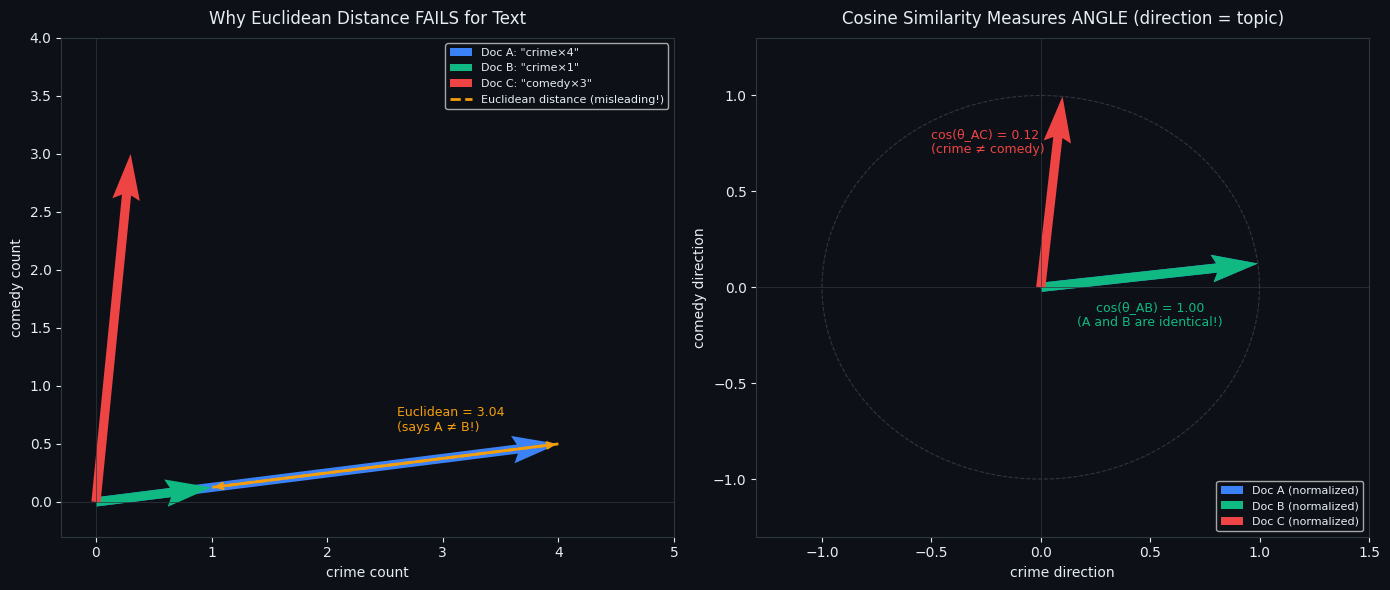


📌 Key insight: Cosine similarity = dot_product(A, B) / (||A|| × ||B||)
   Dividing by magnitudes (||A||, ||B||) REMOVES the length effect.
   Only the DIRECTION (topic) of the vector determines similarity.


In [11]:
# Visualize WHY cosine beats Euclidean for text
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─── Left: The problem illustrated ───────────────────────────────────────────
ax = axes[0]
ax.set_title('Why Euclidean Distance FAILS for Text', color='#e6edf3', pad=10)

# Three vectors
vectors = {
    'Doc A: "crime×4"':    (4, 0.5),   # long crime document
    'Doc B: "crime×1"':    (1, 0.125), # short crime document — SAME direction!
    'Doc C: "comedy×3"':   (0.3, 3.0), # different topic
}
colors = ['#3b82f6', '#10b981', '#ef4444']

for (label, (x, y)), color in zip(vectors.items(), colors):
    ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
              color=color, width=0.015, label=label)

# Euclidean distance between A and B tips
Ax, Ay = 4, 0.5
Bx, By = 1, 0.125
ax.plot([Ax, Bx], [Ay, By], '--', color='#f59e0b', linewidth=2, label='Euclidean distance (misleading!)')
ax.annotate('', xy=(Bx, By), xytext=(Ax, Ay),
            arrowprops=dict(arrowstyle='<->', color='#f59e0b', lw=2))
ax.text((Ax+Bx)/2 + 0.1, (Ay+By)/2 + 0.3, 'Euclidean = 3.04\n(says A ≠ B!)',
        color='#f59e0b', fontsize=9)

ax.set_xlim(-0.3, 5)
ax.set_ylim(-0.3, 4)
ax.set_xlabel('crime count')
ax.set_ylabel('comedy count')
ax.legend(loc='upper right', fontsize=8)
ax.axhline(0, color='#30363d', linewidth=0.5)
ax.axvline(0, color='#30363d', linewidth=0.5)

# ─── Right: Cosine similarity ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_title('Cosine Similarity Measures ANGLE (direction = topic)', color='#e6edf3', pad=10)

theta = np.linspace(0, 2*np.pi, 100)
ax2.plot(np.cos(theta), np.sin(theta), '--', color='#30363d', linewidth=0.8)

# All vectors normalized to unit circle — only direction matters
unit_vectors = {
    'Doc A (normalized)': (0.992, 0.124),   # crime topic
    'Doc B (normalized)': (0.992, 0.124),   # crime topic — SAME as A!
    'Doc C (normalized)': (0.0995, 0.995),  # comedy topic
}

for (label, (x, y)), color in zip(unit_vectors.items(), colors):
    ax2.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
               color=color, width=0.015, label=label)

ax2.text(0.5, -0.2, 'cos(θ_AB) = 1.00\n(A and B are identical!)', color='#10b981', fontsize=9, ha='center')
ax2.text(-0.5, 0.7, 'cos(θ_AC) = 0.12\n(crime ≠ comedy)', color='#ef4444', fontsize=9)

ax2.set_xlim(-1.3, 1.5)
ax2.set_ylim(-1.3, 1.3)
ax2.set_xlabel('crime direction')
ax2.set_ylabel('comedy direction')
ax2.legend(loc='lower right', fontsize=8)
ax2.axhline(0, color='#30363d', linewidth=0.5)
ax2.axvline(0, color='#30363d', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n📌 Key insight: Cosine similarity = dot_product(A, B) / (||A|| × ||B||)")
print("   Dividing by magnitudes (||A||, ||B||) REMOVES the length effect.")
print("   Only the DIRECTION (topic) of the vector determines similarity.")

In [12]:
# Prove it with numbers
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Same topic, different document lengths
doc_a = np.array([[4.0, 0.0]])   # "crime crime crime crime"
doc_b = np.array([[1.0, 0.0]])   # "crime"
doc_c = np.array([[0.0, 3.0]])   # "comedy comedy comedy" — different topic

print("── Euclidean Distance ──────────────────────")
print(f"A vs B (same topic, diff length): {euclidean_distances(doc_a, doc_b)[0,0]:.3f}  ← WRONG, says they differ!")
print(f"A vs C (different topic):          {euclidean_distances(doc_a, doc_c)[0,0]:.3f}")

print()
print("── Cosine Similarity ───────────────────────")
print(f"A vs B (same topic, diff length): {cosine_similarity(doc_a, doc_b)[0,0]:.3f}  ← CORRECT: identical direction!")
print(f"A vs C (different topic):          {cosine_similarity(doc_a, doc_c)[0,0]:.3f}  ← CORRECT: completely different")

print()
print("✅ Use cosine similarity for TEXT — length-invariant, measures topic alignment.")

── Euclidean Distance ──────────────────────
A vs B (same topic, diff length): 3.000  ← WRONG, says they differ!
A vs C (different topic):          5.000

── Cosine Similarity ───────────────────────
A vs B (same topic, diff length): 1.000  ← CORRECT: identical direction!
A vs C (different topic):          0.000  ← CORRECT: completely different

✅ Use cosine similarity for TEXT — length-invariant, measures topic alignment.


---
## 🎬 Putting It All Together: Movie Recommender

Now let's run ALL methods on a real dataset (IMDB top 1000 movies) and compare recommendations.

In [13]:
import os

# Load IMDB dataset — adjust path if needed
CSV_PATH = '../movie_recommender/backend/data/imdb_top_1000.csv'  # local path

if not os.path.exists(CSV_PATH):
    # Colab fallback: try to download
    print("CSV not found locally. Please upload imdb_top_1000.csv to this notebook's folder.")
    print("Or provide the path below:")
    CSV_PATH = input("CSV path: ").strip()

df = pd.read_csv(CSV_PATH)
print(f"✅ Loaded {len(df)} movies")
print(df[['Series_Title', 'Genre', 'IMDB_Rating', 'Overview']].head(3))

✅ Loaded 1000 movies
               Series_Title                 Genre  IMDB_Rating  \
0  The Shawshank Redemption                 Drama          9.3   
1             The Godfather          Crime, Drama          9.2   
2           The Dark Knight  Action, Crime, Drama          9.0   

                                            Overview  
0  Two imprisoned men bond over a number of years...  
1  An organized crime dynasty's aging patriarch t...  
2  When the menace known as the Joker wreaks havo...  


In [14]:
import re

# Build combined text for each movie
def clean(text):
    return re.sub(r'[^a-z\s]', ' ', str(text).lower()).strip()

df['text'] = (df['Overview'].fillna('') + ' ' +
              df['Genre'].fillna('') + ' ' +
              df['Director'].fillna(''))
df['text_clean'] = df['text'].apply(clean)

corpus_full  = df['text_clean'].tolist()
tokenized_full = [t.split() for t in corpus_full]
titles = df['Series_Title'].tolist()

print("Building all 4 similarity matrices (takes ~1 minute)...")

# BoW
bow_mat  = CountVectorizer(max_features=8000, stop_words='english').fit_transform(corpus_full)
S_bow    = cosine_similarity(bow_mat)
print("  ✅ BoW")

# TF-IDF
tfidf_mat = TfidfVectorizer(max_features=8000, ngram_range=(1,2), stop_words='english').fit_transform(corpus_full)
S_tfidf   = cosine_similarity(tfidf_mat)
print("  ✅ TF-IDF")

# Word2Vec (train on corpus)
w2v = Word2Vec(tokenized_full, vector_size=100, window=5, min_count=1, sg=0, epochs=30, seed=42)
w2v_vecs_full = np.array([doc_vector(w2v, t, 100) for t in tokenized_full])
S_w2v = cosine_similarity(w2v_vecs_full)
print("  ✅ Word2Vec")

# FastText (train on corpus)
ft  = FastText(tokenized_full, vector_size=100, window=5, min_count=1, sg=1, epochs=30, seed=42)
ft_vecs_full = np.array([doc_vector(ft, t, 100) for t in tokenized_full])
S_ft = cosine_similarity(ft_vecs_full)
print("  ✅ FastText")


print("\n✅ All matrices ready!")

Building all 4 similarity matrices (takes ~1 minute)...
  ✅ BoW
  ✅ TF-IDF


  ✅ Word2Vec


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  ✅ FastText

✅ All matrices ready!


In [15]:
# Compare all 4 methods for a chosen movie
QUERY_MOVIE = "The Dark Knight"   # ← change this to any IMDB top-1000 movie

idx = titles.index(QUERY_MOVIE)

methods = {
    'Bag of Words':  S_bow,
    'TF-IDF':        S_tfidf,
    'Word2Vec CBOW': S_w2v,
    'FastText':      S_ft,
}

print(f'\n🎬 Movies similar to "{QUERY_MOVIE}":')
print('=' * 90)

comparison = {}
for method_name, S in methods.items():
    scores = S[idx]
    top_idx = np.argsort(-scores)
    top5    = [titles[i] for i in top_idx if i != idx][:5]
    comparison[method_name] = top5
    print(f"{method_name:<18} → {', '.join(top5[:3])}")

print('=' * 90)
print("   TF-IDF finds movies sharing rare keywords (like character names or locations).")
print("   BoW just counts common words — surprisingly effective for genre/director matching!")


🎬 Movies similar to "The Dark Knight":
Bag of Words       → Batman Begins, The Dark Knight Rises, Kill Bill: Vol. 1
TF-IDF             → The Dark Knight Rises, Batman Begins, Interstellar
Word2Vec CBOW      → Malcolm X, Paan Singh Tomar, Kind Hearts and Coronets
FastText           → Butch Cassidy and the Sundance Kid, Serbuan maut 2: Berandal, High Noon
   TF-IDF finds movies sharing rare keywords (like character names or locations).
   BoW just counts common words — surprisingly effective for genre/director matching!


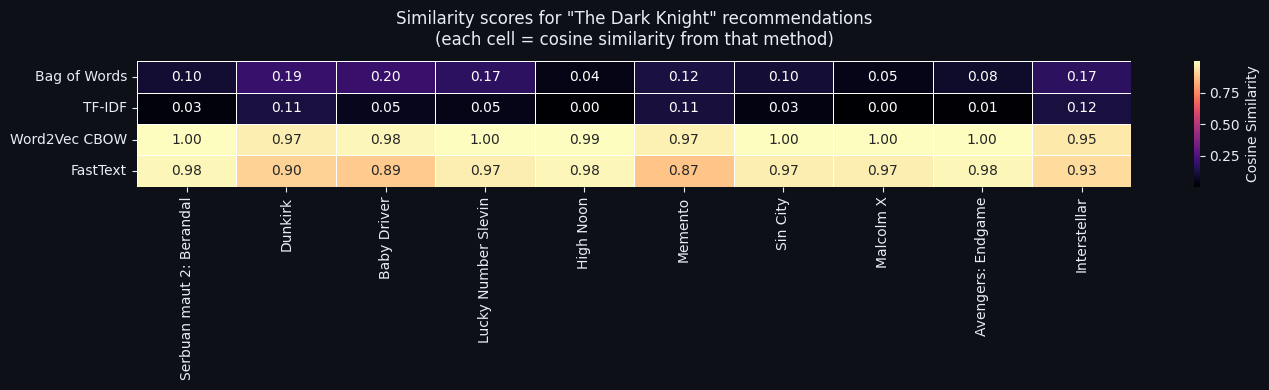


🔑 Summary:
  One-Hot     → no meaningful similarity (all zeros)
  BoW         → works on word overlap; fast; fragile to synonyms
  TF-IDF      → weights rare words; great for search
  Word2Vec    → semantic word vectors; needs large corpus
  FastText    → handles OOV/typos; character n-grams

  For ALL methods: similarity = cosine similarity (angle, not distance)


In [16]:
# Heatmap: how similar are the TOP-10 recommendations across methods?
all_recs = set()
for recs in comparison.values():
    all_recs.update(recs[:5])
all_recs = list(all_recs)[:10]

heat_data = []
for method_name, S in methods.items():
    row = [S[idx][titles.index(m)] if m in titles else 0 for m in all_recs]
    heat_data.append(row)

heat_df = pd.DataFrame(heat_data, index=methods.keys(),
                       columns=[m[:25]+'…' if len(m)>25 else m for m in all_recs])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='magma',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cosine Similarity'})
ax.set_title(f'Similarity scores for "{QUERY_MOVIE}" recommendations\n(each cell = cosine similarity from that method)', pad=12)
plt.tight_layout()
plt.show()

print("\n🔑 Summary:")
print("  One-Hot     → no meaningful similarity (all zeros)")
print("  BoW         → works on word overlap; fast; fragile to synonyms")
print("  TF-IDF      → weights rare words; great for search")
print("  Word2Vec    → semantic word vectors; needs large corpus")
print("  FastText    → handles OOV/typos; character n-grams")
print("\n  For ALL methods: similarity = cosine similarity (angle, not distance)")